In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
# Confirm builds before running gradient computations
print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.11.0+cu130
numpy: 2.2.6


In [29]:
# requires_grad=True instructs autograd to track all operations on this tensor
# so that .backward() can later compute gradients through the computation graph
x = torch.tensor(2.0, requires_grad=True)
print("x:", x)

x: tensor(2., requires_grad=True)


In [30]:
# y = x^2; .backward() walks the graph from y back to x and accumulates dy/dx into x.grad
y = x ** 2
y.backward()
# dy/dx = 2x → at x=2: dy/dx = 4
print("y = x²:", y)
print("dy/dx at x=2:", x.grad)

y = x²: tensor(4., grad_fn=<PowBackward0>)
dy/dx at x=2: tensor(4.)


In [31]:
# Leaf tensors (created directly, not from an operation) accumulate gradients in .grad
# .grad_fn is None for leaves — no op created them, so there is no backward function to record
print("x.data:          ", x.data)
print("x.grad_fn:       ", x.grad_fn)
print("x.grad:          ", x.grad)
print("x.is_leaf:       ", x.is_leaf)
print("x.requires_grad: ", x.requires_grad)

x.data:           tensor(2.)
x.grad_fn:        None
x.grad:           tensor(4.)
x.is_leaf:        True
x.requires_grad:  True


In [32]:
# Non-leaf tensors produced by operations carry a .grad_fn pointing to their creating op
print("y.data:          ", y.data)
print("y.grad_fn:       ", y.grad_fn)
print("y.grad:          None by default for non-leaf tensors")
print("y.is_leaf:       ", y.is_leaf)
print("y.requires_grad: ", y.requires_grad)

# If you explicitly need .grad on a non-leaf tensor, call .retain_grad() before backward()
x_demo = torch.tensor(2.0, requires_grad=True)
y_demo = x_demo ** 2
y_demo.retain_grad()
y_demo.backward()
print("y_demo.grad after retain_grad():", y_demo.grad)

y.data:           tensor(4.)
y.grad_fn:        <PowBackward0 object at 0x78d0bdfe4790>
y.grad:          None by default for non-leaf tensors
y.is_leaf:        False
y.requires_grad:  True
y_demo.grad after retain_grad(): tensor(1.)


In [33]:
# Autograd handles arbitrary compositions — no manual differentiation needed
# dy/dx = 2x + 2 → at x=2: dy/dx = 6
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 2 * x + 1
y.backward()
print("y = x²+2x+1 at x=2:", y)
print("dy/dx at x=2:", x.grad)

y = x²+2x+1 at x=2: tensor(9., grad_fn=<AddBackward0>)
dy/dx at x=2: tensor(6.)


In [34]:
# Subclass torch.autograd.Function to define a custom forward/backward pair
# ctx.save_for_backward() caches tensors from the forward pass for use in backward
# backward must multiply its result by grad_output to correctly apply the chain rule
class Square(torch.autograd.Function):
    @staticmethod
    def forward(ctx, i):
        ctx.save_for_backward(i)
        return i ** 2

    @staticmethod
    def backward(ctx, grad_output):
        (i,) = ctx.saved_tensors
        return 2 * i * grad_output

In [35]:
# .apply() is the public entry point — never call .forward() directly
x = torch.tensor(2.0, requires_grad=True)
y = Square.apply(x)
y.backward()
# Same result as built-in autograd: dy/dx = 2x = 4
print("grad_fn:", y.grad_fn)
print("dy/dx at x=2:", x.grad)

grad_fn: <torch.autograd.function.SquareBackward object at 0x78d0c1a0d690>
dy/dx at x=2: tensor(4.)


In [36]:
# A single .backward() computes gradients w.r.t. all leaves that have requires_grad=True
# ∂f/∂u = v + 2u → at u=1, v=2: ∂f/∂u = 4
# ∂f/∂v = u     → at u=1:       ∂f/∂v = 1
u = torch.tensor(1.0, requires_grad=True)
v = torch.tensor(2.0, requires_grad=True)
f = u * v + u ** 2
f.backward()
print("f(u=1, v=2):", f)
print("∂f/∂u:", u.grad)
print("∂f/∂v:", v.grad)

f(u=1, v=2): tensor(3., grad_fn=<AddBackward0>)
∂f/∂u: tensor(4.)
∂f/∂v: tensor(1.)


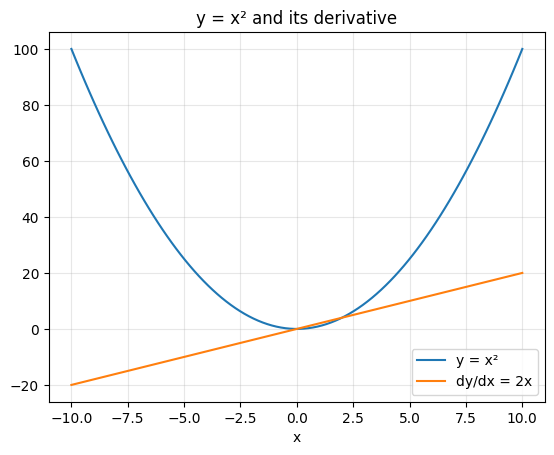

In [37]:
x = torch.linspace(-10, 10, 100, requires_grad=True)
Y = x ** 2
# .backward() requires a scalar; .sum() reduces the vector Y to one so the call is valid,
# and autograd treats it as computing the sum of independent per-element derivatives
Y.sum().backward()

# .detach() is required before .numpy() because x still has requires_grad=True
plt.plot(x.detach().numpy(), Y.detach().numpy(), label="y = x²")
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label="dy/dx = 2x")
plt.xlabel("x")
plt.legend()
plt.grid(alpha=0.3)
plt.title("y = x² and its derivative")
plt.show()

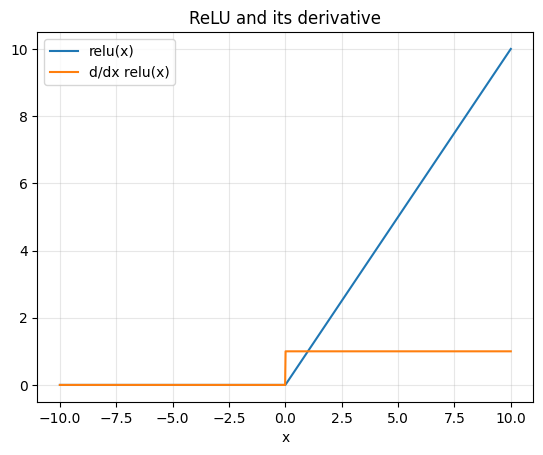

In [38]:
# ReLU is not differentiable at 0; autograd uses the subgradient convention: 0 for x<0, 1 for x>0
x = torch.linspace(-10, 10, 1000, requires_grad=True)
Y = torch.relu(x)
# .backward() requires a scalar; .sum() reduces the vector Y to one so the call is valid,
# and autograd treats it as computing the sum of independent per-element derivatives
Y.sum().backward()

plt.plot(x.detach().numpy(), Y.detach().numpy(), label="relu(x)")
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label="d/dx relu(x)")
plt.xlabel("x")
plt.legend()
plt.grid(alpha=0.3)
plt.title("ReLU and its derivative")
plt.show()

In [39]:
# .detach() returns a tensor sharing data with the original but removed from the graph
# Calling .numpy() directly on a grad-tracked tensor raises RuntimeError
x = torch.linspace(-5, 5, 6, requires_grad=True)
y = x ** 3
print("y values:", y.detach().numpy())
print("grad_fn still intact on original y:", y.grad_fn)

y values: [-125.  -27.   -1.    1.   27.  125.]
grad_fn still intact on original y: <PowBackward0 object at 0x78d0bdebcdf0>
